# Amazon Sales Dataset — EDA, Visualization & Recommendation System

This notebook explores 1,465 Amazon product listings (ratings, prices, reviews) and builds:
1. **Exploratory Data Analysis (EDA)**
2. **Data Visualizations**
3. **A Recommendation System** (Popularity-based, Content-based, and an Item-based Collaborative Filtering demo)

**How to use in Google Colab:**
1. Open this notebook in Colab (`File > Upload notebook`, or drag it into colab.research.google.com).
2. Run the first cell to install packages.
3. Run the "Load Data" cell — it will prompt you to upload `amazon_sales_dataset.csv` (or mount Drive — see comments).


In [1]:
# 1. Install & Import required libraries
!pip -q install wordcloud

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity, linear_kernel

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
pd.set_option("display.max_colwidth", 100)


In [2]:
# 2. Load the data
# Option A: Upload directly in Colab
from google.colab import files
uploaded = files.upload()  # select amazon_sales_dataset.csv when prompted
filename = list(uploaded.keys())[0]

# Option B (alternative): mount Google Drive and read from there instead
# from google.colab import drive
# drive.mount('/content/drive')
# filename = '/content/drive/MyDrive/amazon_sales_dataset.csv'

df = pd.read_csv(filename)
print(df.shape)
df.head()


Saving amazon sales dataset.csv to amazon sales dataset.csv
(1465, 16)


,product_id,product_name,category,discounted_price,actual_price,discount_percentage,rating,rating_count,about_product,user_id,user_name,review_id,review_title,review_content,img_link,product_link
0,B07JW9H4J1,Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatible for iPhone 13...,Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹399,"₹1,099",64%,4.2,"24,269","High Compatibility : Compatible With iPhone 12, 11, X/XsMax/Xr ,iPhone 8/8 Plus,iPhone 7/7 Plus,...","AG3D6O4STAQKAY2UVGEUV46KN35Q,AHMY5CWJMMK5BJRBBSNLYT3ONILA,AHCTC6ULH4XB6YHDY6PCH2R772LQ,AGYHHIERN...","Manav,Adarsh gupta,Sundeep,S.Sayeed Ahmed,jaspreet singh,Khaja moin,Anand,S.ARUMUGAM","R3HXWT0LRP0NMF,R2AJM3LFTLZHFO,R6AQJGUP6P86,R1KD19VHEDV0OR,R3C02RMYQMK6FC,R39GQRVBUZBWGY,R2K9EDOE...","Satisfied,Charging is really fast,Value for money,Product review,Good quality,Good product,Good ...","Looks durable Charging is fine tooNo complains,Charging is really fast, good product.,Till now s...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/51UsScvHQNL._SX300_SY300_QL70_FMwebp...,https://www.amazon.in/Wayona-Braided-WN3LG1-Syncing-Charging/dp/B07JW9H4J1/ref=sr_1_1?qid=167290...
1,B098NS6PVG,"Ambrane Unbreakable 60W / 3A Fast Charging 1.5m Braided Type C Cable for Smartphones, Tablets, L...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹199,₹349,43%,4.0,"43,994","Compatible with all Type C enabled devices, be it an android smartphone (Mi, Samsung, Oppo, Vivo...","AECPFYFQVRUWC3KGNLJIOREFP5LQ,AGYYVPDD7YG7FYNBXNGXZJT525AQ,AHONIZU3ICIEHQIGQ6R2VFRSBXOQ,AFPHD2CRP...","ArdKn,Nirbhay kumar,Sagar Viswanathan,Asp,Placeholder,BharanI,sonia,Niam","RGIQEG07R9HS2,R1SMWZQ86XIN8U,R2J3Y1WL29GWDE,RYGGS0M09S3KY,R17KQRUTAN5DKS,R3AAQGS6HP2QUK,R1HDNOG6...","A Good Braided Cable for Your Type C Device,Good quality product from ambrane,Super cable,As,Goo...",I ordered this cable to connect my phone to Android Auto of car. The cable is really strong and ...,https://m.media-amazon.com/images/W/WEBP_402378-T2/images/I/31zOsqQOAOL._SY445_SX342_QL70_FMwebp...,https://www.amazon.in/Ambrane-Unbreakable-Charging-Braided-Cable/dp/B098NS6PVG/ref=sr_1_2?qid=16...
2,B096MSW6CT,"Sounce Fast Phone Charging Cable & Data Sync USB Cable Compatible for iPhone 13, 12,11, X, 8, 7,...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹199,"₹1,899",90%,3.9,"7,928",【 Fast Charger& Data Sync】-With built-in safety proctections and four-core copper wires promote ...,"AGU3BBQ2V2DDAMOAKGFAWDDQ6QHA,AESFLDV2PT363T2AQLWQOWZ4N3OA,AHTPQRIMGUD4BYR5YIHBH3CCGEFQ,AEUVWXYP5...","Kunal,Himanshu,viswanath,sai niharka,saqib malik,Aashiq,Ramu Challa,Sanjay gupta","R3J3EQQ9TZI5ZJ,R3E7WBGK7ID0KV,RWU79XKQ6I1QF,R25X4TBMPY91LX,R27OK7G99VK0TR,R207CYDCHJJTCJ,R3PCU8X...","Good speed for earlier versions,Good Product,Working good,Good for the price,Good,Worth for mone...","Not quite durable and sturdy,https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/71rIggr...",https://m.media-amazon.com/images/W/WEBP_402378-T1/images/I/31IvNJZnmdL._SY445_SX342_QL70_FMwebp...,https://www.amazon.in/Sounce-iPhone-Charging-Compatible-Devices/dp/B096MSW6CT/ref=sr_1_3?qid=167...
3,B08HDJ86NZ,"boAt Deuce USB 300 2 in 1 Type-C & Micro USB Stress Resistant, Tangle-Free, Sturdy Cable with 3A...",Computers&Accessories|Accessories&Peripherals|Cables&Accessories|Cables|USBCables,₹329,₹699,53%,4.2,"94,363","The boAt Deuce USB 300 2 in 1 cable is compatible with smartphones, tablets, PC peripherals, Blu...","AEWAZDZZJLQUYVOVGBEUKSLXHQ5A,AG5HTSFRRE6NL3M5SGCUQBP7YSCA,AH725ST5NW2Y4JZPKUNTIJCUK2BA,AHV3TXIFC...","Omkar dhale,JD,HEMALATHA,Ajwadh a.,amar singh chouhan,Ravi Siddan,Himanshu Goel,Udaykumar","R3EEUZKKK9J36I,R3HJVYCLYOY554,REDECAZ7AMPQC,R1CLH2ULIVG5U3,R2DMKIBGFKBD6R,RC89B5IAJUTR5,R3B3DDON...","Good product,Good one,Nice,Really nice product,Very first time change,Good,Fine product but coul...","Good product,long wire,Charges 

## 3. Initial Inspection

In [3]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1465 entries, 0 to 1464
Data columns (total 16 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   product_id           1465 non-null   object
 1   product_name         1465 non-null   object
 2   category             1465 non-null   object
 3   discounted_price     1465 non-null   object
 4   actual_price         1465 non-null   object
 5   discount_percentage  1465 non-null   object
 6   rating               1465 non-null   object
 7   rating_count         1463 non-null   object
 8   about_product        1465 non-null   object
 9   user_id              1465 non-null   object
 10  user_name            1465 non-null   object
 11  review_id            1465 non-null   object
 12  review_title         1465 non-null   object
 13  review_content       1465 non-null   object
 14  img_link             1465 non-null   object
 15  product_link         1465 non-null   object
dtypes: obj

In [4]:
df.isnull().sum()


,0
product_id,0
product_name,0
category,0
discounted_price,0
actual_price,0
discount_percentage,0
rating,0
rating_count,2
about_product,0
user_id,0


In [5]:
# Duplicate rows / unique products
print("Duplicate rows:", df.duplicated().sum())
print("Unique product_id:", df['product_id'].nunique(), "out of", len(df), "rows")


Duplicate rows: 0
Unique product_id: 1351 out of 1465 rows


## 4. Data Cleaning

The numeric-looking columns (`discounted_price`, `actual_price`, `discount_percentage`, `rating`,
`rating_count`) are stored as text with currency symbols, commas, and `%` signs, so we need to
convert them to proper numeric types. There is also one known bad row where `rating == '|'`.


In [6]:
def clean_price(x):
    return pd.to_numeric(str(x).replace('₹', '').replace(',', '').strip(), errors='coerce')

def clean_percent(x):
    return pd.to_numeric(str(x).replace('%', '').strip(), errors='coerce')

def clean_count(x):
    return pd.to_numeric(str(x).replace(',', '').strip(), errors='coerce')

df['discounted_price'] = df['discounted_price'].apply(clean_price)
df['actual_price']     = df['actual_price'].apply(clean_price)
df['discount_percentage'] = df['discount_percentage'].apply(clean_percent)
df['rating']        = pd.to_numeric(df['rating'].replace('|', np.nan), errors='coerce')
df['rating_count']  = df['rating_count'].apply(clean_count)

# Drop rows where rating or rating_count could not be parsed (should be very few)
before = len(df)
df = df.dropna(subset=['rating', 'rating_count']).reset_index(drop=True)
print(f"Dropped {before - len(df)} rows with unparseable rating/rating_count")

df[['discounted_price','actual_price','discount_percentage','rating','rating_count']].describe()


Dropped 3 rows with unparseable rating/rating_count


,discounted_price,actual_price,discount_percentage,rating,rating_count
count,1462.000000,1462.000000,1462.000000,1462.000000,1462.000000
mean,3129.981826,5453.087743,47.672367,4.096717,18307.376881
std,6950.548042,10884.467444,21.613905,0.289497,42766.096572
min,39.000000,39.000000,0.000000,2.000000,2.000000
25%,325.000000,800.000000,32.000000,4.000000,1191.500000
50%,799.000000,1670.000000,50.000000,4.100000,5179.000000
75%,1999.000000,4321.250000,63.000000,4.300000,17342.250000
max,77990.000000,139900.000000,94.000000,5.000000,426973.000000


In [7]:
# Break the pipe-separated category hierarchy into a top-level (main) category
df['main_category'] = df['category'].apply(lambda x: str(x).split('|')[0])
df['sub_category']  = df['category'].apply(lambda x: str(x).split('|')[-1])

print(df['main_category'].nunique(), "main categories")
df['main_category'].value_counts().head(10)


9 main categories


,count
main_category,
Electronics,526
Computers&Accessories,451
Home&Kitchen,447
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


## 5. Exploratory Data Analysis

In [8]:
# Distribution of ratings
print(df['rating'].describe())
print("\nMost common rating values:")
print(df['rating'].value_counts().sort_index())


count    1462.000000
mean        4.096717
std         0.289497
min         2.000000
25%         4.000000
50%         4.100000
75%         4.300000
max         5.000000
Name: rating, dtype: float64

Most common rating values:
rating
2.0      1
2.3      1
2.6      1
2.8      2
2.9      1
3.0      3
3.1      4
3.2      2
3.3     16
3.4     10
3.5     26
3.6     35
3.7     42
3.8     86
3.9    123
4.0    181
4.1    244
4.2    228
4.3    230
4.4    123
4.5     75
4.6     17
4.7      6
4.8      3
5.0      2
Name: count, dtype: int64


In [9]:
# Top 10 main categories by number of products
top_cat = df['main_category'].value_counts().head(10)
top_cat


,count
main_category,
Electronics,526
Computers&Accessories,451
Home&Kitchen,447
OfficeProducts,31
MusicalInstruments,2
HomeImprovement,2
Toys&Games,1
Car&Motorbike,1
Health&PersonalCare,1


In [10]:
# Correlation between price, discount and rating
corr_cols = ['discounted_price','actual_price','discount_percentage','rating','rating_count']
df[corr_cols].corr()


,discounted_price,actual_price,discount_percentage,rating,rating_count
discounted_price,1.000000,0.961910,-0.242298,0.121132,-0.027304
actual_price,0.961910,1.000000,-0.117855,0.122467,-0.036215
discount_percentage,-0.242298,-0.117855,1.000000,-0.155679,0.011294
rating,0.121132,0.122467,-0.155679,1.000000,0.102235
rating_count,-0.027304,-0.036215,0.011294,0.102235,1.000000


In [11]:
# Top 10 highest-rated products with a meaningful number of reviews (rating_count >= 1000)
df[df['rating_count'] >= 1000] \
  .sort_values(['rating','rating_count'], ascending=False) \
  [['product_name','main_category','rating','rating_count','discounted_price']] \
  .drop_duplicates('product_name') \
  .head(10)


,product_name,main_category,rating,rating_count,discounted_price
1143,Swiffer Instant Electric Water Heater Faucet Tap Home-Kitchen Instantaneous Water Heater Tank le...,Home&Kitchen,4.8,53803.0,1439.0
1296,"Instant Pot Air Fryer, Vortex 2QT, Touch Control Panel, 360° EvenCrisp™ Technology, Uses 95 % le...",Home&Kitchen,4.8,3964.0,4995.0
457,Spigen EZ Fit Tempered Glass Screen Protector for iPhone 14 Pro Max - 2 Pack (Sensor Protection),Electronics,4.7,7779.0,999.0
249,Sony Bravia 164 cm (65 inches) 4K Ultra HD Smart LED Google TV KD-65X74K (Black),Electronics,4.7,5935.0,77990.0
1385,Campfire Spring Chef Prolix Instant Portable Water Heater Geyser 1Ltr. for Use Home Stainless St...,Home&Kitchen,4.7,2591.0,1499.0
1273,Multifunctional 2 in 1 Electric Egg Boiling Steamer Egg Frying Pan Egg Boiler Electric Automatic...,Home&Kitchen,4.7,2300.0,699.0
1221,"FIGMENT Handheld Milk Frother Rechargeable, 3-Speed Electric Frother for Coffee with 2 Whisks an...",Home&Kitchen,4.7,1729.0,699.0
818,Redgear MP35 Speed-Type Gaming Mousepad (Black/Red),Computers&Accessories,4.6,33434.0,299.0
445,Spigen EZ Fit Tempered Glass Screen Protector Guard for iPhone 14/13/13 Pro - 2 Pack,Electronics,4.6,26603.0,999.0
884,"Logitech M331 Silent Plus Wireless Mouse, 2.4GHz with USB Nano Receiver, 1000 DPI Optical Tracki...",Computers&Accessories,4.6,12375.0,1295.0


In [12]:
# Top 10 most-reviewed products
df.sort_values('rating_count', ascending=False) \
  [['product_name','main_category','rating','rating_count']] \
  .drop_duplicates('product_name') \
  .head(10)


,product_name,main_category,rating,rating_count
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - Supports Ethernet, 3D, 4K video,Black",Electronics,4.4,426973.0
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black",Electronics,4.4,426973.0
12,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot",Electronics,4.4,426973.0
398,boAt Bassheads 100 in Ear Wired Earphones with Mic(Furious Red),Electronics,4.1,363713.0
350,boAt Bassheads 100 in Ear Wired Earphones with Mic(Taffy Pink),Electronics,4.1,363713.0
582,boAt BassHeads 100 in-Ear Wired Headphones with Mic (Black),Electronics,4.1,363711.0
368,"Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Storage) | Octa-core Helio G35 | 5000 mAh Battery",Electronics,4.1,313836.0
369,"Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Storage) | 2GHz Octa-core Helio G25 Processor | 5000 ...",Electronics,4.1,313836.0
564,"Redmi 9A Sport (Coral Green, 3GB RAM, 32GB Storage) | 2GHz Octa-core Helio G25 Processor | 5000 ...",Electronics,4.1,313832.0
471,"Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB Storage) | 2GHz Octa-core Helio G25 Processor | 5000...",Electronics,4.1,313832.0


## 6. Data Visualization

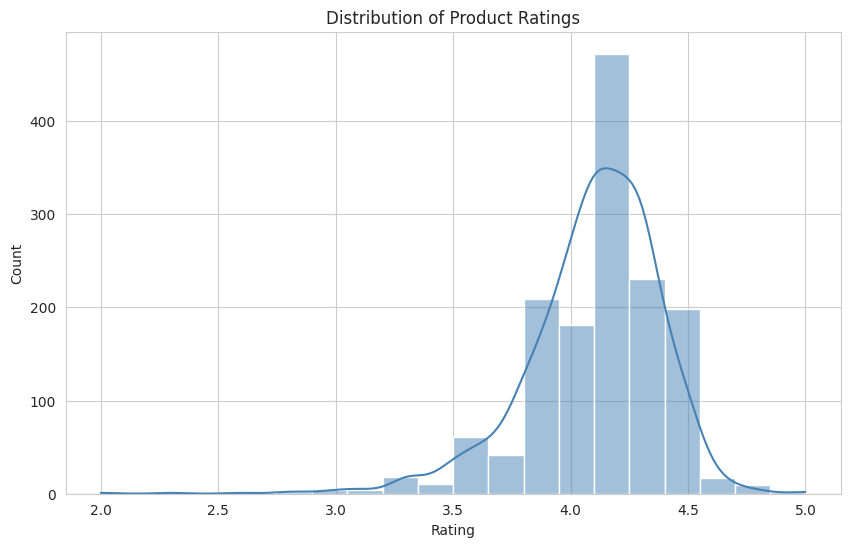

In [13]:
# 6.1 Rating distribution
plt.figure()
sns.histplot(df['rating'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Product Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()


/tmp/ipykernel_1595/1819182541.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cat.values, y=top_cat.index, palette='viridis')


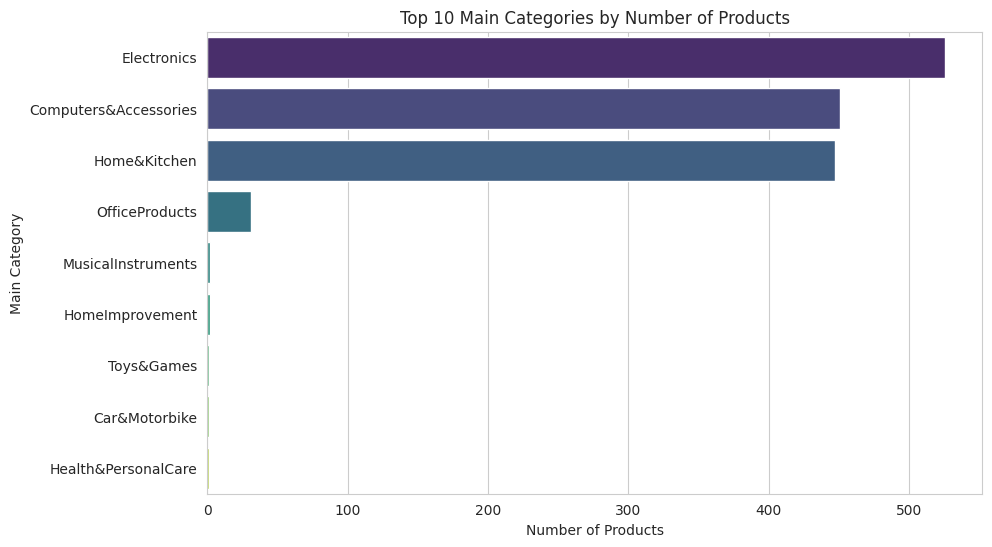

In [14]:
# 6.2 Top 10 categories by number of products
plt.figure()
sns.barplot(x=top_cat.values, y=top_cat.index, palette='viridis')
plt.title('Top 10 Main Categories by Number of Products')
plt.xlabel('Number of Products')
plt.ylabel('Main Category')
plt.show()


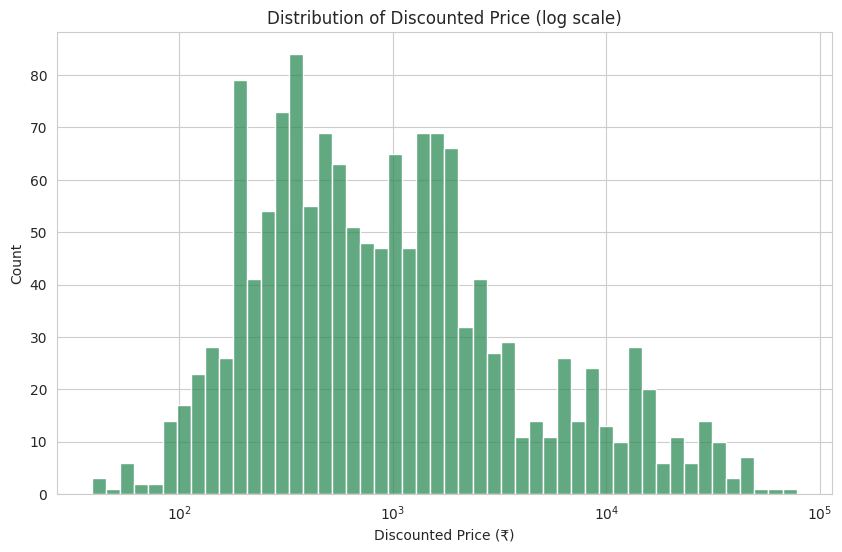

In [15]:
# 6.3 Discounted price distribution (log scale, since prices are highly skewed)
plt.figure()
sns.histplot(df['discounted_price'], bins=50, log_scale=True, color='seagreen')
plt.title('Distribution of Discounted Price (log scale)')
plt.xlabel('Discounted Price (₹)')
plt.show()


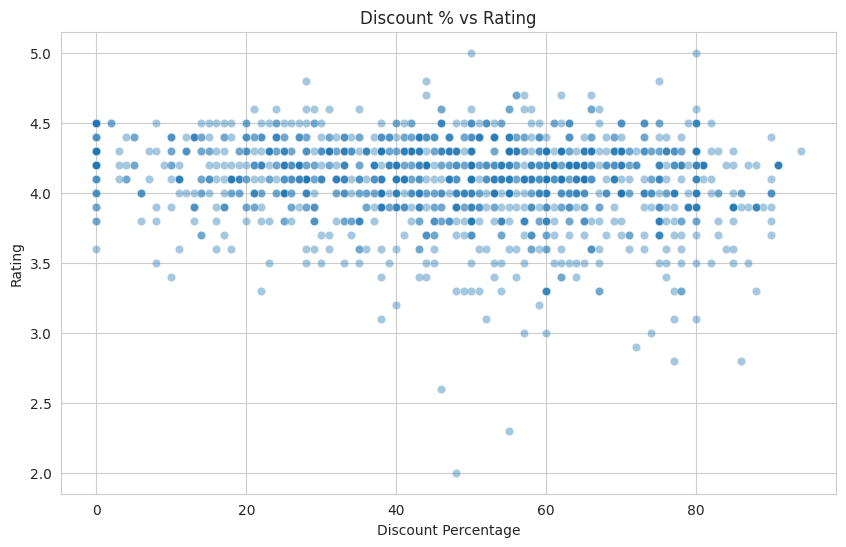

In [16]:
# 6.4 Discount percentage vs Rating
plt.figure()
sns.scatterplot(data=df, x='discount_percentage', y='rating', alpha=0.4)
plt.title('Discount % vs Rating')
plt.xlabel('Discount Percentage')
plt.ylabel('Rating')
plt.show()


/tmp/ipykernel_1595/4149303745.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_rating_cat.values, y=avg_rating_cat.index, palette='mako')


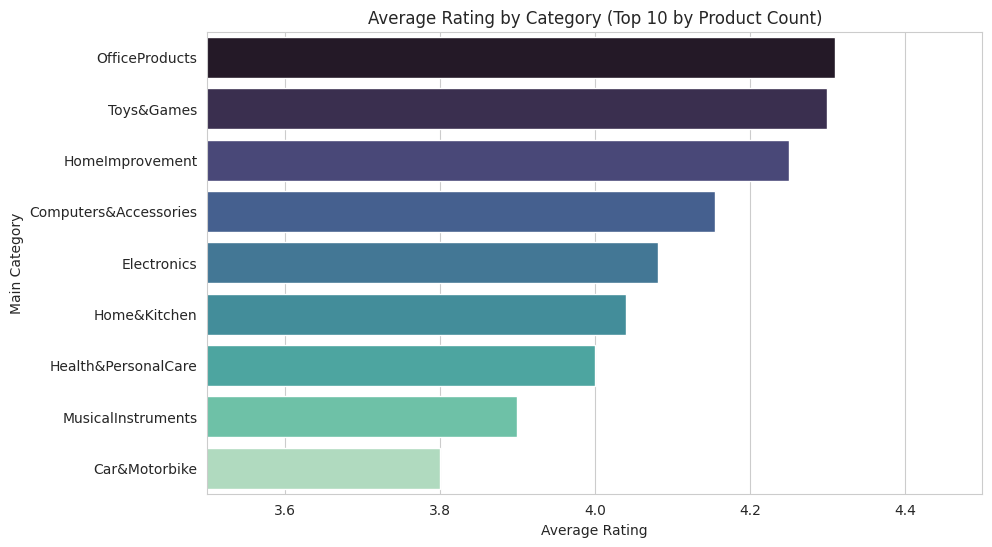

In [17]:
# 6.5 Average rating by top 10 categories
avg_rating_cat = df[df['main_category'].isin(top_cat.index)] \
    .groupby('main_category')['rating'].mean().sort_values(ascending=False)

plt.figure()
sns.barplot(x=avg_rating_cat.values, y=avg_rating_cat.index, palette='mako')
plt.title('Average Rating by Category (Top 10 by Product Count)')
plt.xlabel('Average Rating')
plt.ylabel('Main Category')
plt.xlim(3.5, 4.5)
plt.show()


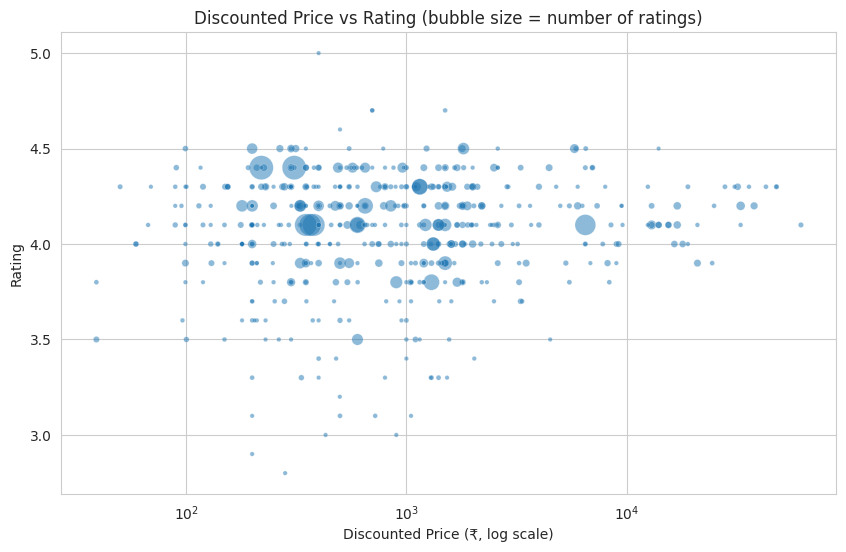

In [18]:
# 6.6 Price vs Rating, sized by number of ratings
plt.figure()
sample = df.sample(min(500, len(df)), random_state=42)
sns.scatterplot(data=sample, x='discounted_price', y='rating',
                 size='rating_count', sizes=(10, 300), alpha=0.5, legend=False)
plt.xscale('log')
plt.title('Discounted Price vs Rating (bubble size = number of ratings)')
plt.xlabel('Discounted Price (₹, log scale)')
plt.ylabel('Rating')
plt.show()


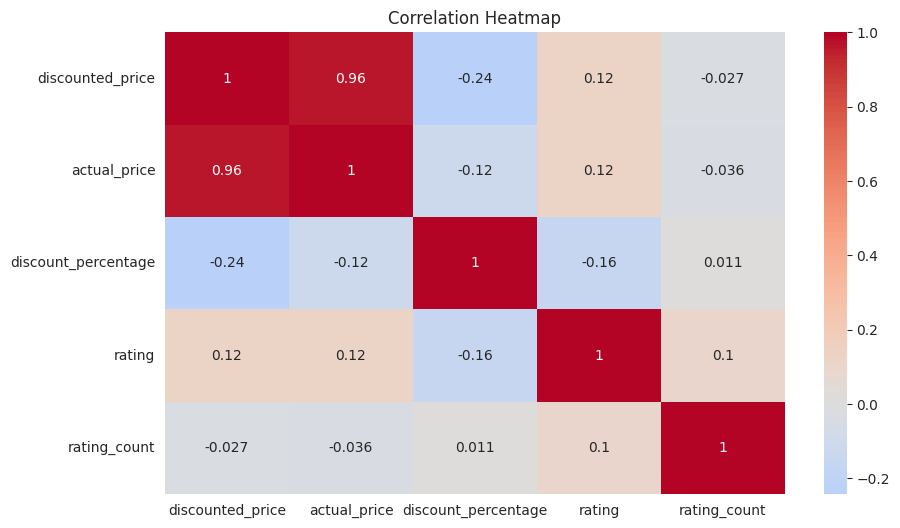

In [19]:
# 6.7 Correlation heatmap
plt.figure()
sns.heatmap(df[corr_cols].corr(), annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()


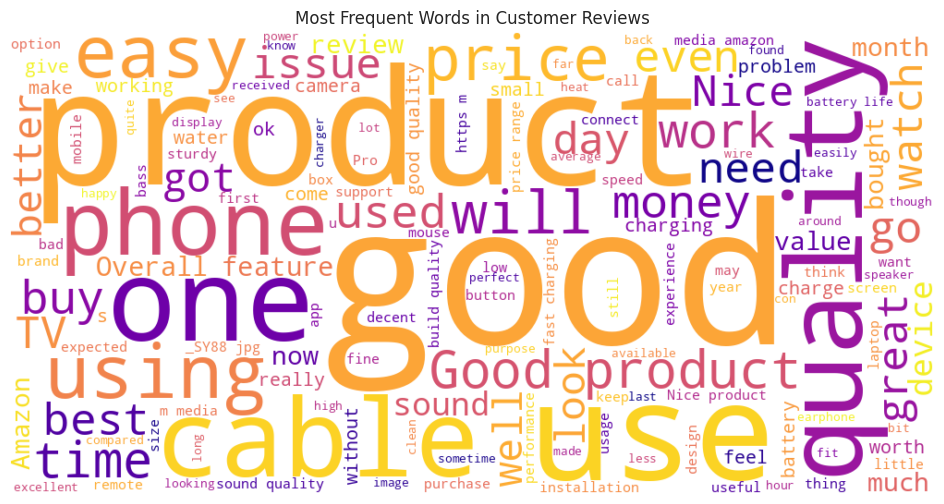

In [20]:
# 6.8 Word cloud of frequently mentioned words in review content
text = ' '.join(df['review_content'].dropna().astype(str).tolist())
wc = WordCloud(width=1000, height=500, background_color='white',
               stopwords=STOPWORDS, max_words=150, colormap='plasma').generate(text)

plt.figure(figsize=(12,6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title('Most Frequent Words in Customer Reviews')
plt.show()


## 7. Recommendation System

We build three complementary recommenders:

1. **Popularity-based** — ranks products with an IMDB-style weighted rating (balances rating value
   against number of votes, so a 5.0 with 3 reviews doesn't outrank a 4.6 with 50,000 reviews).
2. **Content-based** — uses TF-IDF over product name, category, and description text, then
   recommends similar products via cosine similarity. Good for "more like this" recommendations.
3. **Item-based Collaborative Filtering (demo)** — the dataset embeds multiple `user_id`s per
   product row (reviewers of that product). We explode this into a user–item interaction table
   and compute item-item similarity from co-review patterns. Note: this dataset has no per-user
   rating value, only an aggregate product rating, so this CF demo uses **co-review overlap**
   (which products tend to be reviewed by the same users) rather than true rating-based CF —
   a useful illustration, but treat it as a proof of concept rather than production-grade CF.


In [21]:
# 7.1 Popularity-based recommender (weighted rating, IMDB formula)
C = df['rating'].mean()                 # mean rating across all products
m = df['rating_count'].quantile(0.70)   # minimum votes required to be considered

def weighted_rating(row, m=m, C=C):
    v = row['rating_count']
    R = row['rating']
    return (v / (v + m) * R) + (m / (v + m) * C)

products = df.drop_duplicates('product_id').copy()
products['weighted_score'] = products.apply(weighted_rating, axis=1)

def popular_products(category=None, top_n=10):
    pool = products if category is None else products[products['main_category'] == category]
    return pool.sort_values('weighted_score', ascending=False) \
               [['product_name','main_category','rating','rating_count','weighted_score']] \
               .head(top_n)

print("Top 10 overall:")
popular_products()


Top 10 overall:


,product_name,main_category,rating,rating_count,weighted_score
1143,Swiffer Instant Electric Water Heater Faucet Tap Home-Kitchen Instantaneous Water Heater Tank le...,Home&Kitchen,4.8,53803.0,4.655651
862,SanDisk Extreme SD UHS I 64GB Card for 4K Video for DSLR and Mirrorless Cameras 170MB/s Read & 8...,Electronics,4.5,205052.0,4.474407
40,"AmazonBasics USB 2.0 Cable - A-Male to B-Male - for Personal Computer, Printer- 6 Feet (1.8 Mete...",Computers&Accessories,4.5,107687.0,4.453911
818,Redgear MP35 Speed-Type Gaming Mousepad (Black/Red),Computers&Accessories,4.6,33434.0,4.452245
808,Crucial BX500 240GB 3D NAND SATA 6.35 cm (2.5-inch) SSD (CT240BX500SSD1),Computers&Accessories,4.5,92925.0,4.447541
212,"AmazonBasics USB 2.0 Extension Cable for Personal Computer, Printer, 2-Pack - A-Male to A-Female...",Computers&Accessories,4.5,74977.0,4.436947
30,"AmazonBasics USB 2.0 - A-Male to A-Female Extension Cable for Personal Computer, Printer (Black,...",Computers&Accessories,4.5,74976.0,4.436947
445,Spigen EZ Fit Tempered Glass Screen Protector Guard for iPhone 14/13/13 Pro - 2 Pack,Electronics,4.6,26603.0,4.427322
732,"Logitech M235 Wireless Mouse, 1000 DPI Optical Tracking, 12 Month Life Battery, Compatible with ...",Computers&Accessories,4.5,54405.0,4.417956
623,Seagate Expansion 1TB External HDD - USB 3.0 for Windows and Mac with 3 yr Data Recovery Service...,Computers&Accessories,4.5,50810.0,4.413397


In [22]:
print("Top 10 in a specific category, e.g. 'Electronics':")
popular_products(category='Electronics', top_n=10)


Top 10 in a specific category, e.g. 'Electronics':


,product_name,main_category,rating,rating_count,weighted_score
862,SanDisk Extreme SD UHS I 64GB Card for 4K Video for DSLR and Mirrorless Cameras 170MB/s Read & 8...,Electronics,4.5,205052.0,4.474407
445,Spigen EZ Fit Tempered Glass Screen Protector Guard for iPhone 14/13/13 Pro - 2 Pack,Electronics,4.6,26603.0,4.427322
12,"AmazonBasics Flexible Premium HDMI Cable (Black, 4K@60Hz, 18Gbps), 3-Foot",Electronics,4.4,426973.0,4.390441
47,"Amazon Basics High-Speed HDMI Cable, 6 Feet - Supports Ethernet, 3D, 4K video,Black",Electronics,4.4,426973.0,4.390441
65,"Amazon Basics High-Speed HDMI Cable, 6 Feet (2-Pack),Black",Electronics,4.4,426973.0,4.390441
474,"ELV Aluminum Adjustable Mobile Phone Foldable Tabletop Stand Dock Mount for All Smartphones, Tab...",Electronics,4.5,28978.0,4.369297
578,Elv Aluminium Adjustable Mobile Phone Foldable Holder Tabletop Stand Dock Mount for All Smartpho...,Electronics,4.5,28978.0,4.369297
613,"Duracell Ultra Alkaline AA Battery, 8 Pcs",Electronics,4.5,28030.0,4.366342
786,"SanDisk Ultra SDHC UHS-I Card 32GB 120MB/s R for DSLR Cameras, for Full HD Recording, 10Y Warranty",Electronics,4.4,69585.0,4.349519
129,"AmazonBasics 3.5mm to 2-Male RCA Adapter Cable For Tablet, Smartphone (Black, 15 feet)",Electronics,4.4,69538.0,4.349491


In [23]:
# 7.2 Content-based recommender (TF-IDF + cosine similarity)
products = products.reset_index(drop=True)
products['content'] = (
    products['product_name'].fillna('') + ' ' +
    products['category'].fillna('').str.replace('|', ' ') + ' ' +
    products['about_product'].fillna('')
)

tfidf = TfidfVectorizer(stop_words='english', max_features=20000)
tfidf_matrix = tfidf.fit_transform(products['content'])
print("TF-IDF matrix shape:", tfidf_matrix.shape)

cosine_sim = linear_kernel(tfidf_matrix, tfidf_matrix)

indices = pd.Series(products.index, index=products['product_name']).drop_duplicates()

def recommend_similar(product_name, top_n=10):
    if product_name not in indices:
        matches = products[products['product_name'].str.contains(product_name, case=False, na=False)]
        if matches.empty:
            return f"No product found matching '{product_name}'"
        idx = matches.index[0]
    else:
        idx = indices[product_name]

    sim_scores = list(enumerate(cosine_sim[idx]))
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)[1:top_n+1]
    product_indices = [i[0] for i in sim_scores]

    result = products.iloc[product_indices][['product_name','main_category','rating','rating_count']].copy()
    result['similarity'] = [s for _, s in sim_scores]
    return result

# Example: recommend products similar to the first product in the dataset
sample_product = products['product_name'].iloc[0]
print("Recommendations similar to:", sample_product[:80], "...\n")
recommend_similar(sample_product, top_n=10)


TF-IDF matrix shape: (1348, 10358)
Recommendations similar to: Wayona Nylon Braided USB to Lightning Fast Charging and Data Sync Cable Compatib ...



,product_name,main_category,rating,rating_count,similarity
220,"Wayona Nylon Braided Usb Syncing And Charging Cable Sync And Charging Cable For Iphone, Ipad (3 ...",Computers&Accessories,4.2,24269.0,0.948893
42,"Wayona Nylon Braided 3A Lightning to USB A Syncing and Fast Charging Data Cable for iPhone, Ipad...",Computers&Accessories,4.2,24269.0,0.918176
89,"Wayona Nylon Braided (2 Pack) Lightning Fast Usb Data Cable Fast Charger Cord For Iphone, Ipad T...",Computers&Accessories,4.2,24269.0,0.916845
80,"Wayona Usb Nylon Braided Data Sync And Charging Cable For Iphone, Ipad Tablet (Red, Black)",Computers&Accessories,4.2,24269.0,0.775097
166,"Wayona Nylon Braided Lightning USB Data Sync & 3A Charging Cable for iPhones, iPad Air, iPad Min...",Computers&Accessories,4.2,13120.0,0.748713
106,Wayona Nylon Braided 2M / 6Ft Fast Charge Usb To Lightning Data Sync And Charging Cable For Ipho...,Computers&Accessories,4.2,24269.0,0.741963
208,MYVN LTG to USB for Fast Charging & Data Sync USB Cable Compatible for iPhone 5/5s/6/6S/7/7+/8/8...,Computers&Accessories,3.7,2249.0,0.640208
104,"Wayona Nylon Braided USB Data Sync and Fast Charging 3A Short Power Bank Cable For iPhones, iPad...",Computers&Accessories,4.2,13120.0,0.510379
78,"SWAPKART Fast Charging Cable and Data Sync USB Cable Compatible for iPhone 6/6S/7/7+/8/8+/10/11,...",Computers&Accessories,3.9,536.0,0.496146
186,"AmazonBasics USB C to Lightning Aluminum with Nylon Braided MFi Certified Charging Cable (Grey, ...",Computers&Accessories,4.4,13552.0,0.473544


In [24]:
# Try it with a keyword search, e.g. any product containing 'headphone'
recommend_similar('headphone', top_n=10)


,product_name,main_category,rating,rating_count,similarity
33,"Samsung Original Type C to C Cable - 3.28 Feet (1 Meter), White",Computers&Accessories,4.3,355.0,0.497278
162,"Pinnaclz Original Combo of 2 USB Type C Fast Charging Cable, USB C Data Cable for Charging and D...",Computers&Accessories,4.0,7732.0,0.441361
73,"Pinnaclz Original Combo of 2 Micro USB Fast Charging Cable, USB Charging Cable for Data Transfer...",Computers&Accessories,4.0,7732.0,0.438524
293,AmazonBasics USB Type-C to Micro-B 2.0 Cable - 6 Inches (15.2 Centimeters) - White,Computers&Accessories,4.1,14896.0,0.417897
15,MI Braided USB Type-C Cable for Charging Adapter (Red),Computers&Accessories,4.4,18757.0,0.409929
247,"AmazonBasics USB Type-C to USB Type-C 2.0 Cable for Charging Adapter, Smartphone - 9 Feet (2.7 M...",Computers&Accessories,4.2,29746.0,0.408563
97,"Gilary Multi Charging Cable, 3 in 1 Nylon Braided Fast Charging Cable for iPhone Micro USB Type ...",Computers&Accessories,3.7,1097.0,0.405997
235,"Belkin USB C to USB-C Fast Charging Type C Cable, 60W PD, 3.3 feet (1 meter) for Laptop, Persona...",Computers&Accessories,4.5,474.0,0.399160
63,AmazonBasics USB Type-C to USB Type-C 2.0 Cable - 3 Feet Laptop (0.9 Meters) - White,Computers&Accessories,4.2,29746.0,0.398918
69,"Amazon Basics USB Type-C to USB-A 2.0 Male Fast Charging Cable for Laptop - 3 Feet (0.9 Meters),...",Computers&Accessories,4.3,20053.0,0.388395


In [25]:
# 7.3 Item-based Collaborative Filtering demo (co-review overlap)
# Explode the comma-separated user_id / review columns into one row per (product, user) pair

def split_col(x):
    return [s.strip() for s in str(x).split(',')]

pairs = []
for _, row in df.iterrows():
    users = split_col(row['user_id'])
    for u in users:
        pairs.append((row['product_id'], u))

interactions = pd.DataFrame(pairs, columns=['product_id', 'user_id']).drop_duplicates()
print("Total interactions:", len(interactions))
print("Unique users:", interactions['user_id'].nunique())

# Build a sparse user-item matrix (binary: reviewed or not)
from scipy.sparse import csr_matrix

user_cat = interactions['user_id'].astype('category')
item_cat = interactions['product_id'].astype('category')

ui_matrix = csr_matrix(
    (np.ones(len(interactions)), (item_cat.cat.codes, user_cat.cat.codes))
)
item_ids = item_cat.cat.categories

# Item-item similarity from shared reviewers
item_sim = cosine_similarity(ui_matrix)
item_sim_df = pd.DataFrame(item_sim, index=item_ids, columns=item_ids)

def recommend_cf(product_id, top_n=10):
    if product_id not in item_sim_df.index:
        return f"Product ID '{product_id}' not found in interaction matrix"
    scores = item_sim_df[product_id].drop(product_id).sort_values(ascending=False).head(top_n)
    rec = products.set_index('product_id').loc[scores.index][['product_name','main_category','rating']]
    rec['co_review_similarity'] = scores.values
    return rec

sample_id = df['product_id'].iloc[0]
print("CF recommendations for product_id:", sample_id)
recommend_cf(sample_id, top_n=10)


Total interactions: 10594
Unique users: 9040
CF recommendations for product_id: B07JW9H4J1


,product_name,main_category,rating,co_review_similarity
B07JGDB5M1,Wayona Nylon Braided 2M / 6Ft Fast Charge Usb To Lightning Data Sync And Charging Cable For Ipho...,Computers&Accessories,4.2,1.000
B07LGT55SJ,"Wayona Usb Nylon Braided Data Sync And Charging Cable For Iphone, Ipad Tablet (Red, Black)",Computers&Accessories,4.2,1.000
B07JW1Y6XV,"Wayona Nylon Braided 3A Lightning to USB A Syncing and Fast Charging Data Cable for iPhone, Ipad...",Computers&Accessories,4.2,1.000
B07JH1C41D,"Wayona Nylon Braided (2 Pack) Lightning Fast Usb Data Cable Fast Charger Cord For Iphone, Ipad T...",Computers&Accessories,4.2,1.000
B07JH1CBGW,"Wayona Nylon Braided Usb Syncing And Charging Cable Sync And Charging Cable For Iphone, Ipad (3 ...",Computers&Accessories,4.2,1.000
B097C564GC,"rts [2 Pack] Mini USB C Type C Adapter Plug, Type C Female to USB A Male Charger Charging Cable ...",Computers&Accessories,4.3,0.125
B09DL9978Y,"Hindware Atlantic Compacto 3 Litre Instant water heater with Stainless Steel Tank, Robust Constr...",Home&Kitchen,4.1,0.000
B09GB5B4BK,"HP 150 Wireless USB Mouse with Ergonomic and ambidextrous Design, 1600 DPI Optical Tracking, 2.4...",Computers&Accessories,4.0,0.000
B09G5TSGXV,"Hi-Mobiler iPhone Charger Lightning Cable,2 Pack Apple MFi Certified USB iPhone Fast Chargering ...",Computers&Accessories,4.0,0.000
B09G2VTHQM,"AGARO Classic Portable Yogurt Maker, 1.2L Capacity, Electric, Automatic, Grey and White, Medium ...",Home&Kitchen,4.1,0.000


## 8. Summary

- Cleaned and typed all price/rating/discount fields, fixed one malformed rating row.
- Explored rating distribution, category mix, price patterns, and text of customer reviews.
- Built three recommenders:
  - **Popularity-based** — great as a "trending / best overall" fallback, especially per category.
  - **Content-based (TF-IDF)** — good for "similar products" / cold-start items with no reviews yet.
  - **Item-based CF (co-review overlap)** — illustrates collaborative filtering mechanics on this
    dataset's embedded reviewer IDs; a real production system would want true per-user star ratings
    and timestamps to do this properly (e.g. via matrix factorization).
- A natural next step: combine all three into a **hybrid recommender** (e.g. weighted blend of
  content similarity and popularity score, filtered to the user's preferred category).
